In [2]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
from datetime import datetime, timedelta, timezone

In [3]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
russell1000 = market.retrieve("russell1000")
market.disconnect()

In [4]:
tickers = russell1000["ticker"].values
training_year = datetime.now().year - 3
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4

In [5]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        ticker_prices["historical_volatility"] = ticker_prices["adjclose"].rolling(100).std() / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["historical_return"] = ticker_prices["adjclose"] / ticker_prices["adjclose"].rolling(100).mean()
        ticker_prices["historical_bollinger"] = ticker_prices["adjclose"] / (ticker_prices["adjclose"].rolling(100).mean() - 2 * ticker_prices["adjclose"].rolling(100).std()) 
        ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
        ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
        ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-5)
        ticker_prices["sell_date"] = ticker_prices["date"] + timedelta(days=7)
        # ticker_prices["sell_date"] = ticker_prices["date"].shift(-holding_period)
        prices.append(ticker_prices)
    except Exception as e:
        print(ticker,str(e))
        continue
market.disconnect()
sim = pd.concat(prices).reset_index(drop=True)

model_prep: 100%|██████████| 1009/1009 [00:46<00:00, 21.50it/s]


In [6]:
positions = 10
hedge_percentage = 0.05
sim["return"] = (sim["sell_price"] - sim["buy_price"]) / sim ["buy_price"] * (1/positions) * 0.995
sim["return"] = [max(float(-hedge_percentage/positions),x) for x in sim["return"]]
sim.sort_values("date",inplace=True)
trades = sim[sim["weekday"]==weekday].copy()
trades = processor.column_date_processing(trades)

In [7]:
valuation_method = "historical_volatility"

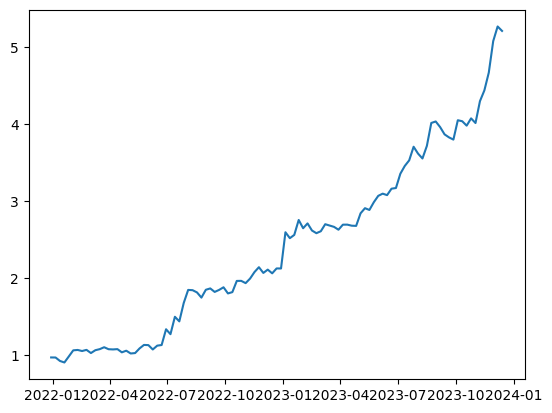

In [13]:
try:
    iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
    portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
    portfolio.sort_values("date",inplace=True)
    portfolio = portfolio[(portfolio["date"]<portfolio["date"].max())]
    portfolio["return"] = portfolio["return"] + 1
    portfolio["cumulative_return"] = portfolio["return"].cumprod()
    portfolio.dropna(inplace=True)
    recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method]].sort_values(["date"]).tail(positions)
    plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
    plt.show()
except Exception as e:
    print(str(e))

In [14]:
portfolio.sort_values("date",ascending=False)

,date,return,cumulative_return
102,2023-12-13 05:00:00+00:00,0.989023,5.206667
101,2023-12-06 05:00:00+00:00,1.037415,5.264457
100,2023-11-29 05:00:00+00:00,1.087501,5.074591
99,2023-11-22 05:00:00+00:00,1.051985,4.666286
98,2023-11-15 05:00:00+00:00,1.032493,4.435696
...,...,...,...
4,2022-01-26 05:00:00+00:00,1.086184,0.986549
3,2022-01-19 05:00:00+00:00,0.978895,0.908270
2,2022-01-12 05:00:00+00:00,0.953910,0.927853
1,2022-01-05 05:00:00+00:00,0.999203,0.972684


In [15]:
iteration_trades.sort_values("return",ascending=False).head(positions)

,index,date,adjclose,ticker,year,quarter,month,week,weekday,historical_volatility,historical_return,historical_bollinger,buy_price,buy_date,sell_price,sell_date,return
25,413544,2023-01-04 05:00:00+00:00,8.45,SHC,2023,1,1,1,2,0.451392,0.844350,8.685382,8.43,2023-01-05 05:00:00+00:00,17.64,2023-01-11 05:00:00+00:00,0.108706
39,113219,2022-07-13 04:00:00+00:00,53.10,COIN,2022,3,7,28,2,0.467860,0.452162,7.034330,53.42,2022-07-14 04:00:00+00:00,75.27,2022-07-20 04:00:00+00:00,0.040698
177,413512,2022-11-16 05:00:00+00:00,6.28,SHC,2022,4,11,46,2,0.430255,0.465661,3.338305,5.95,2022-11-17 05:00:00+00:00,8.25,2022-11-23 05:00:00+00:00,0.038462
210,468209,2023-07-26 04:00:00+00:00,25.34,VRT,2023,3,7,30,2,0.274767,1.410238,3.130624,25.32,2023-07-27 04:00:00+00:00,34.29,2023-08-02 04:00:00+00:00,0.035249
126,108716,2022-08-03 04:00:00+00:00,58.36,NET,2022,3,8,31,2,0.393675,0.803123,3.776739,58.43,2022-08-04 04:00:00+00:00,78.61,2022-08-10 04:00:00+00:00,0.034364
738,478473,2022-06-29 04:00:00+00:00,48.17,W,2022,2,6,26,2,0.370988,0.517011,2.003735,43.56,2022-06-30 04:00:00+00:00,57.94,2022-07-06 04:00:00+00:00,0.032847
784,489093,2022-10-19 04:00:00+00:00,123.07,WING,2022,4,10,42,2,0.211396,1.112154,1.926783,117.22,2022-10-20 04:00:00+00:00,155.45,2022-10-26 04:00:00+00:00,0.032451
716,8010,2023-11-22 05:00:00+00:00,25.57,AFRM,2023,4,11,47,2,0.172636,1.335743,2.040151,26.23,2023-11-24 05:00:00+00:00,34.41,2023-11-29 05:00:00+00:00,0.031030
2,113229,2022-07-27 04:00:00+00:00,58.83,COIN,2022,3,7,30,2,0.494647,0.558809,52.193314,62.25,2022-07-28 04:00:00+00:00,80.81,2022-08-03 04:00:00+00:00,0.029666
897,202951,2022-02-02 05:00:00+00:00,64.02,GTLB,2022,1,2,5,2,NaN,NaN,NaN,61.61,2022-02-03 05:00:00+00:00,78.70,2022-02-09 05:00:00+00:00,0.027600


In [16]:
recommendations

,date,sell_date,ticker,adjclose,historical_bollinger
456,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,M,19.83,2.466864
554,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,RKT,14.30,2.312752
323,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,NVCR,12.92,2.731400
119,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,GPS,20.68,3.836467
552,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,S,26.50,2.314052
532,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,ESTC,110.17,2.342362
18,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,CHPT,2.48,9.928464
123,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,COIN,161.86,3.801429
23,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,HE,13.81,8.961363
37,2023-12-20 05:00:00+00:00,2023-12-27 05:00:00+00:00,AFRM,45.51,7.312880


In [12]:
db.connect()
db.drop('portfolio')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()